# Addiction Population Data — Predictive Modelling

**Goal:** Predict whether an individual **has health issues** (`has_health_issues`) based on socio-demographic, lifestyle, and substance-use features.  
A secondary regression task predicts **smokes_per_day** to quantify smoking intensity.

Pipeline overview:
1. Data Loading & Overview
2. Exploratory Data Analysis (EDA)
3. Pre-processing & Feature Engineering
4. Model Training — Classification (has_health_issues)
5. Model Training — Regression (smokes_per_day)
6. Evaluation & Comparison
7. Feature Importance
8. Model Persistence

## 1. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Regression models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)

import joblib

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Data Loading & Overview

In [2]:
df = pd.read_csv('addiction_population_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3000, 25)


,id,name,age,gender,country,city,education_level,employment_status,annual_income_usd,marital_status,...,attempts_to_quit_smoking,attempts_to_quit_drinking,has_health_issues,mental_health_status,exercise_frequency,diet_quality,sleep_hours,bmi,social_support,therapy_history
0,1,Michael Bates,66,Other,Yemen,Martinmouth,Secondary,Student,45595,Married,...,6,2,True,Good,Daily,Average,5.6,22.4,NaN,Current
1,2,Brian Thompson,29,Male,Saudi Arabia,Harperhaven,Primary,Self-Employed,145842,Single,...,1,6,False,Poor,Weekly,Good,6.7,24.1,Moderate,NaN
2,3,Steven Little,75,Male,Togo,Chanport,Postgraduate,Unemployed,162480,Single,...,9,9,True,Good,Never,Good,6.2,22.2,Weak,NaN
3,4,Michael Mathews,35,Other,Togo,North Cory,University,Unemployed,16023,In a relationship,...,5,7,False,Average,Daily,Good,7.2,25.5,Moderate,Current
4,5,Nicholas Sanchez,38,Female,Morocco,Danielberg,College,Self-Employed,62933,In a relationship,...,4,7,True,Poor,Weekly,Good,8.5,31.2,Weak,Past


In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Data Types ===
id                             int64
name                          object
age                            int64
gender                        object
country                       object
city                          object
education_level               object
employment_status             object
annual_income_usd              int64
marital_status                object
children_count                 int64
smokes_per_day                 int64
drinks_per_week                int64
age_started_smoking            int64
age_started_drinking           int64
attempts_to_quit_smoking       int64
attempts_to_quit_drinking      int64
has_health_issues               bool
mental_health_status          object
exercise_frequency            object
diet_quality                  object
sleep_hours                  float64
bmi                          float64
social_support                object
therapy_history               object
dtype: object

=== Missing Values ===
id                

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,3000.0,NaN,NaN,NaN,1500.5,866.169729,1.0,750.75,1500.5,2250.25,3000.0
name,3000,2944,Laura Johnson,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,3000.0,NaN,NaN,NaN,46.654333,18.74088,15.0,31.0,47.0,63.0,79.0
gender,3000,3,Other,1024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,3000,243,Korea,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,3000,2675,Port Jennifer,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,2580,6,University,464,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_status,3000,5,Self-Employed,634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_income_usd,3000.0,NaN,NaN,NaN,98904.178,57288.035963,560.0,49336.0,98616.5,148622.75,199951.0
marital_status,3000,5,Widowed,651,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Exploratory Data Analysis (EDA)

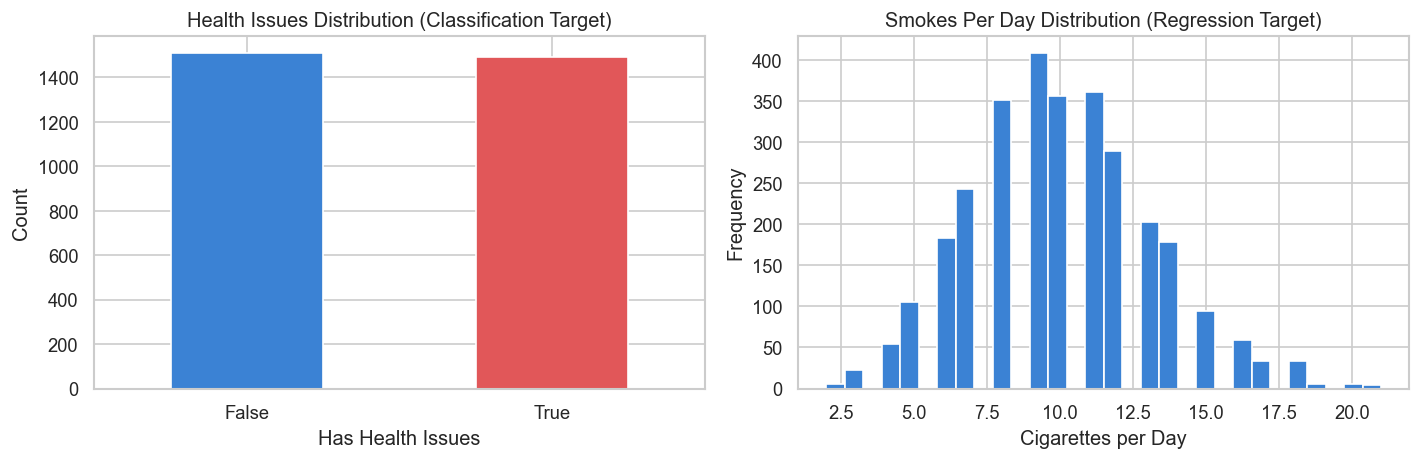

In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['has_health_issues'].value_counts().plot(kind='bar', ax=axes[0], color=['#3b82d4','#e15759'])
axes[0].set_title('Health Issues Distribution (Classification Target)')
axes[0].set_xlabel('Has Health Issues')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['smokes_per_day'].hist(bins=30, ax=axes[1], color='#3b82d4', edgecolor='white')
axes[1].set_title('Smokes Per Day Distribution (Regression Target)')
axes[1].set_xlabel('Cigarettes per Day')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

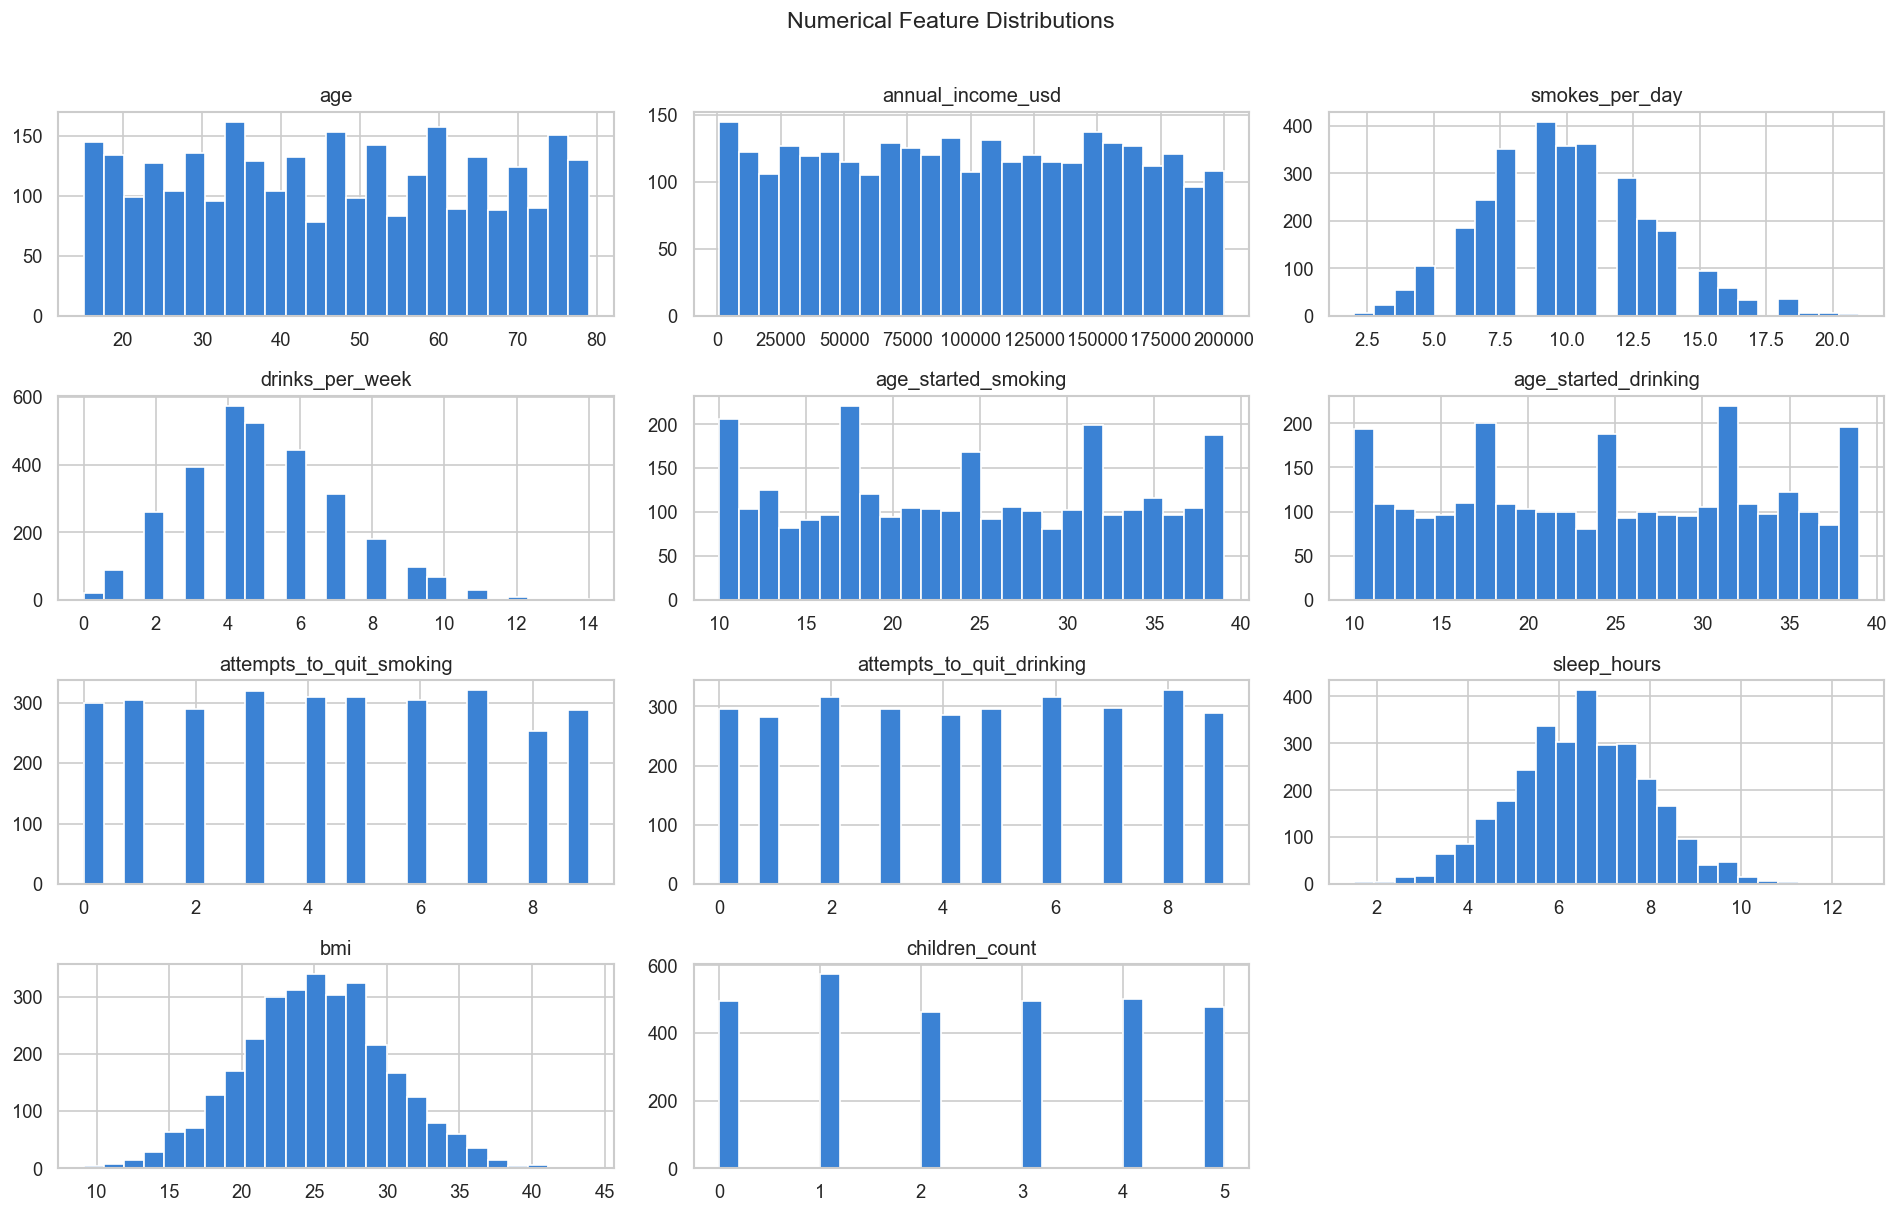

In [6]:
# Numerical feature distributions
num_cols = ['age', 'annual_income_usd', 'smokes_per_day', 'drinks_per_week',
            'age_started_smoking', 'age_started_drinking',
            'attempts_to_quit_smoking', 'attempts_to_quit_drinking',
            'sleep_hours', 'bmi', 'children_count']

df[num_cols].hist(bins=25, figsize=(16, 10), edgecolor='white', color='#3b82d4')
plt.suptitle('Numerical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

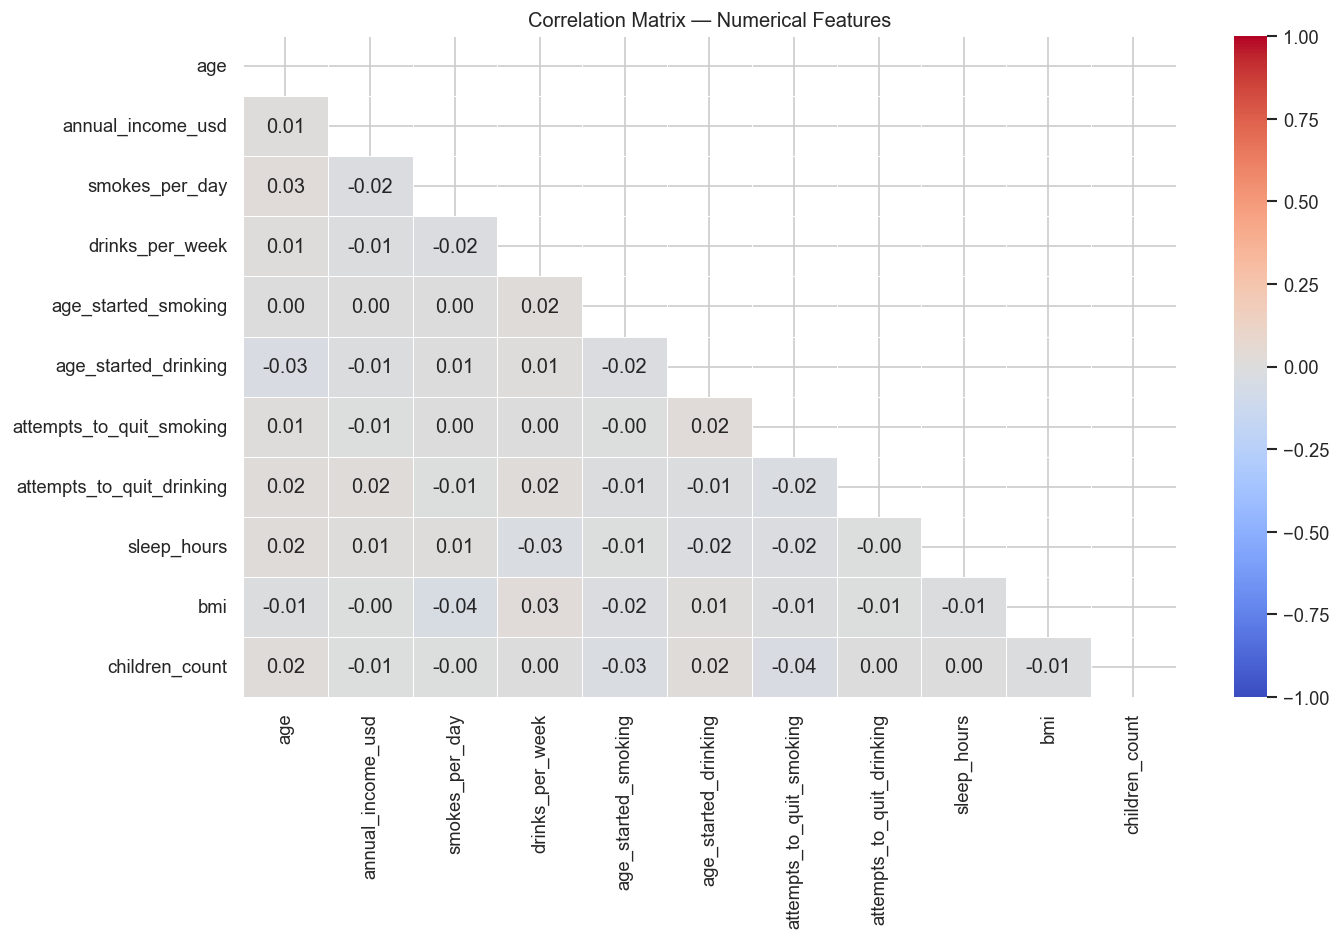

In [7]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

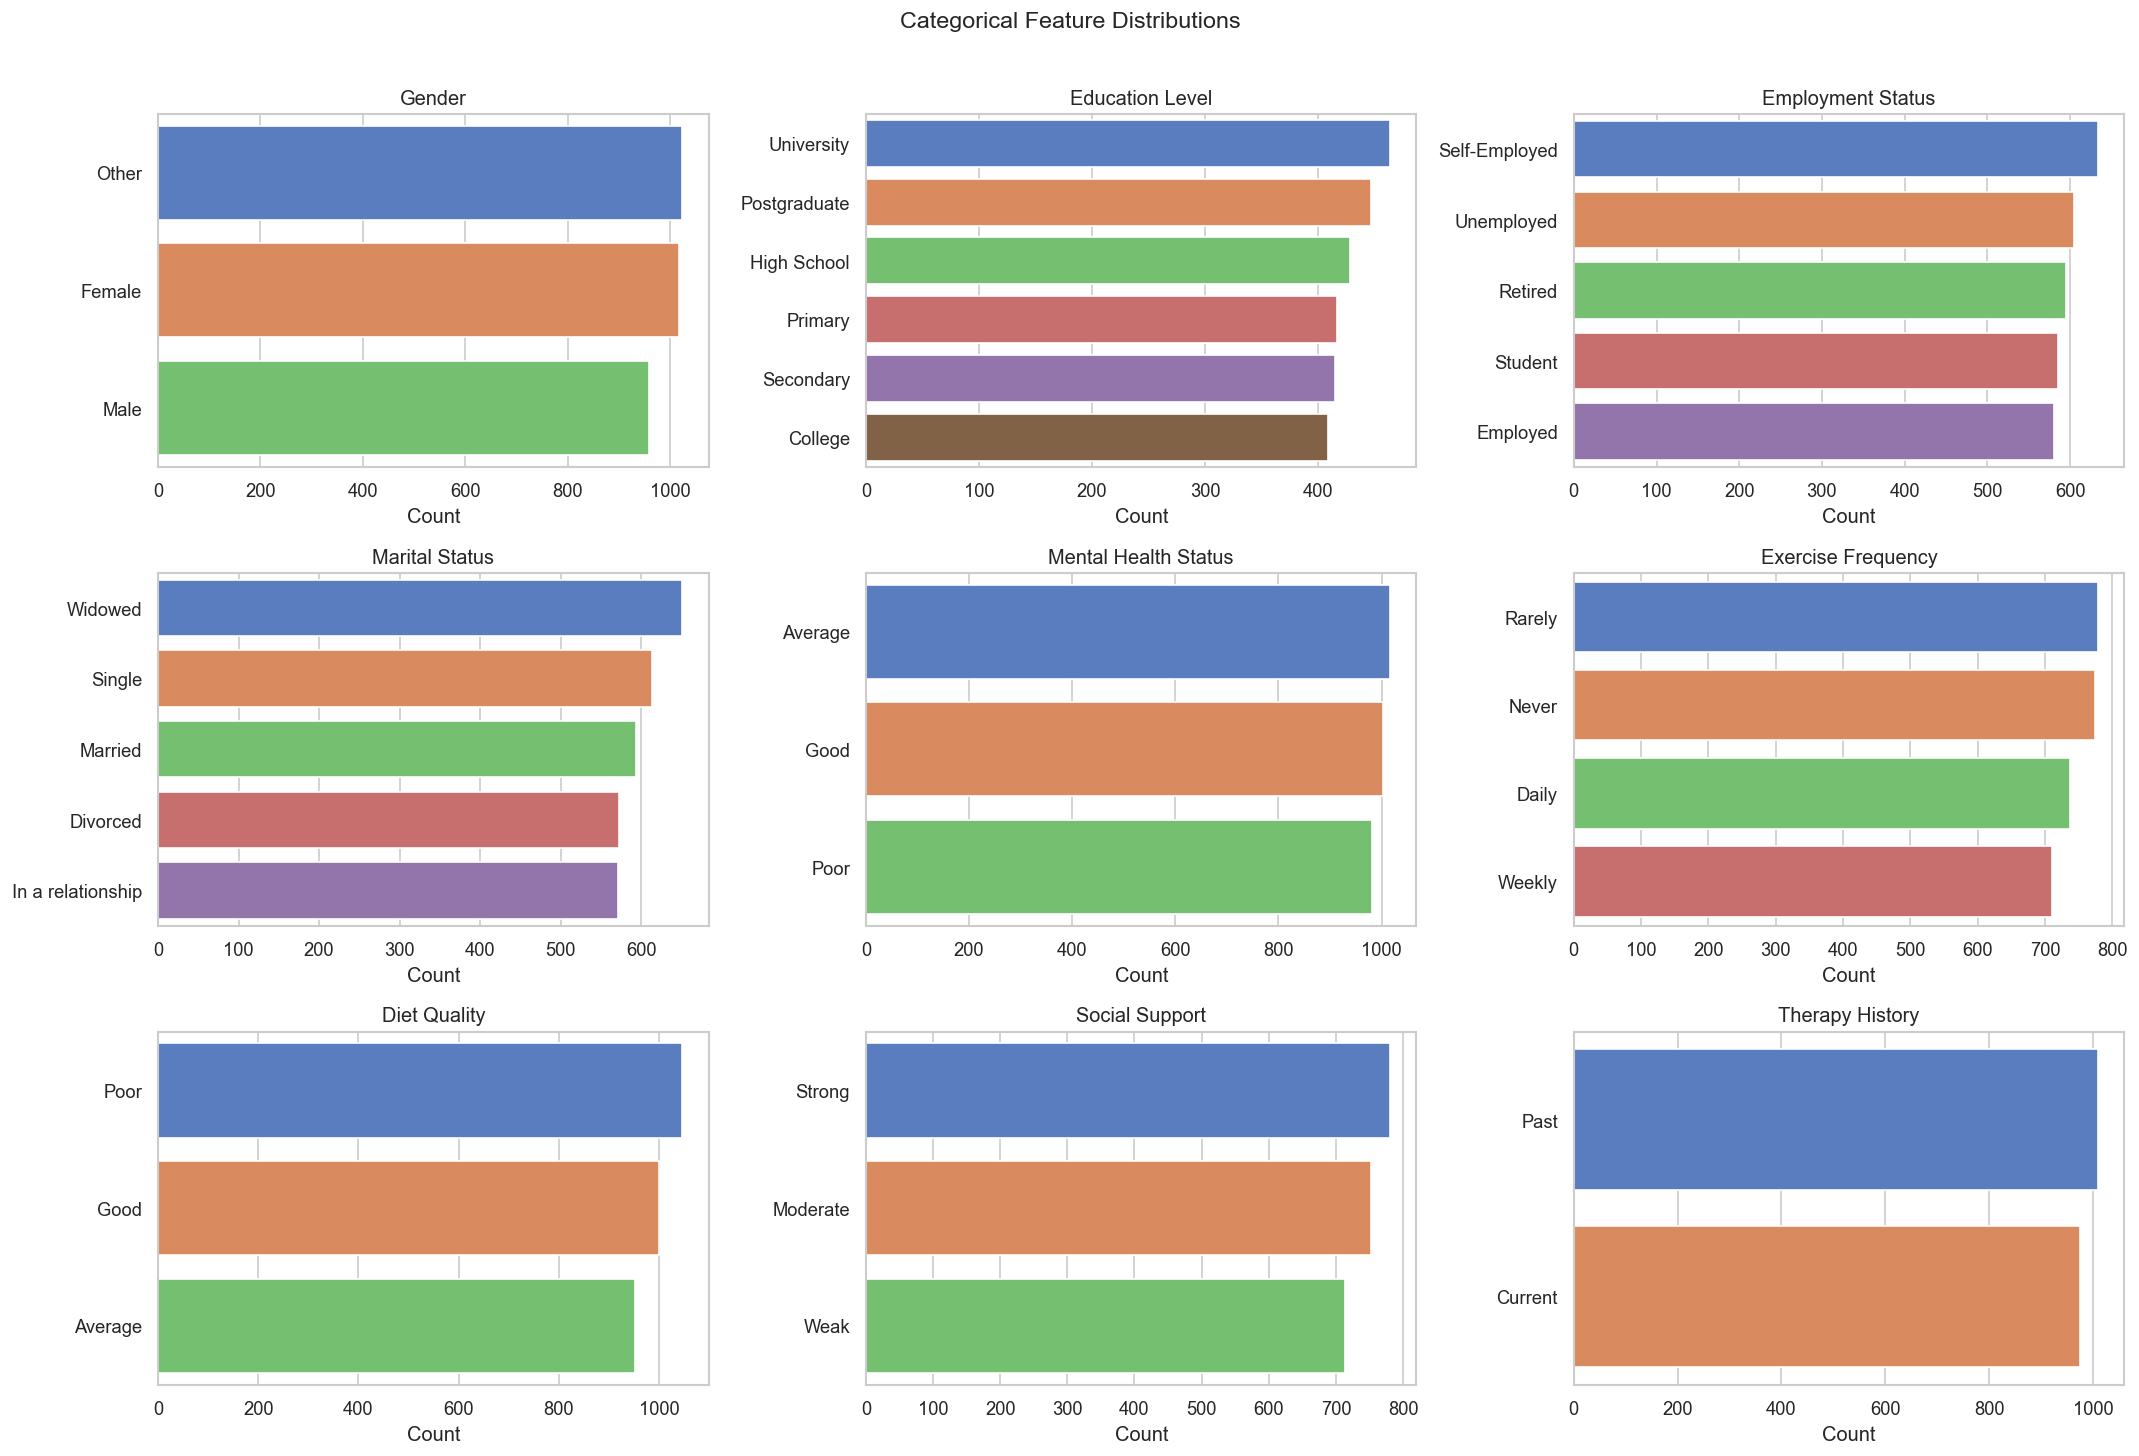

In [8]:
# Categorical feature counts
cat_cols = ['gender', 'education_level', 'employment_status',
            'marital_status', 'mental_health_status',
            'exercise_frequency', 'diet_quality', 'social_support', 'therapy_history']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], palette='muted')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')
plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

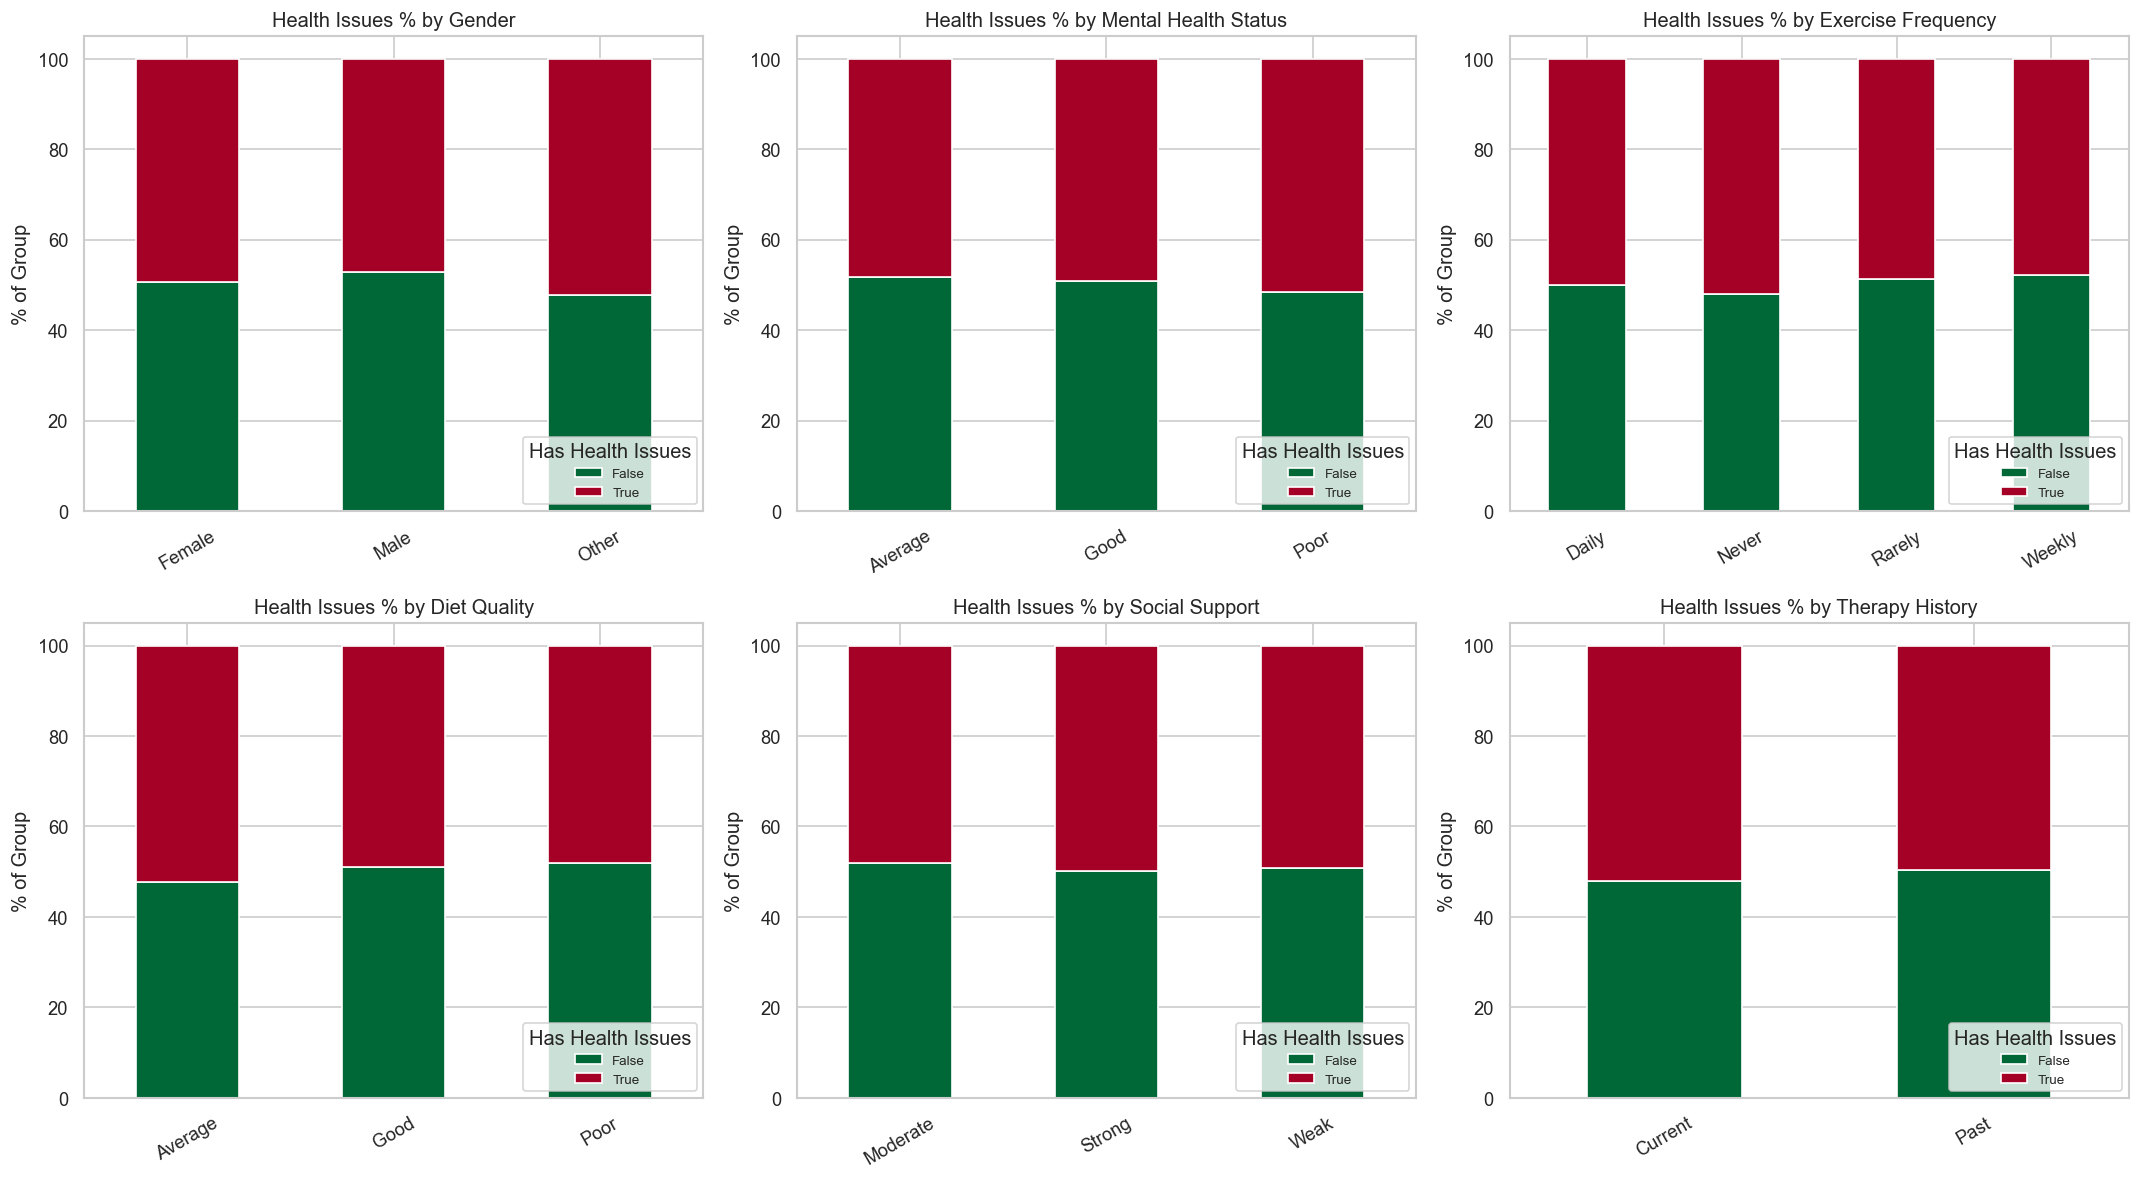

In [9]:
# Health issues breakdown by key categorical features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
key_cats = ['gender', 'mental_health_status', 'exercise_frequency',
             'diet_quality', 'social_support', 'therapy_history']
for i, col in enumerate(key_cats):
    ct = pd.crosstab(df[col], df['has_health_issues'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], stacked=True, colormap='RdYlGn_r', edgecolor='white')
    axes[i].set_title(f'Health Issues % by {col.replace("_", " ").title()}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% of Group')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Has Health Issues', loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## 4. Pre-processing & Feature Engineering

In [10]:
# Drop non-predictive identifier columns
df_model = df.drop(columns=['id', 'name', 'city', 'country'])

# Encode boolean target
df_model['has_health_issues'] = df_model['has_health_issues'].astype(str).str.strip().map(
    {'True': 1, 'False': 0, 'true': 1, 'false': 0, '1': 1, '0': 0}
)

# Feature engineering
df_model['smoking_duration']  = df_model['age'] - df_model['age_started_smoking']
df_model['drinking_duration'] = df_model['age'] - df_model['age_started_drinking']
df_model['total_substance']   = df_model['smokes_per_day'] + df_model['drinks_per_week']
df_model['quit_attempts_total'] = df_model['attempts_to_quit_smoking'] + df_model['attempts_to_quit_drinking']

# Clip negative durations (edge cases where age < age_started)
df_model['smoking_duration']  = df_model['smoking_duration'].clip(lower=0)
df_model['drinking_duration'] = df_model['drinking_duration'].clip(lower=0)

print(f'Feature-engineered shape: {df_model.shape}')
df_model.head(3)

Feature-engineered shape: (3000, 25)


,age,gender,education_level,employment_status,annual_income_usd,marital_status,children_count,smokes_per_day,drinks_per_week,age_started_smoking,...,exercise_frequency,diet_quality,sleep_hours,bmi,social_support,therapy_history,smoking_duration,drinking_duration,total_substance,quit_attempts_total
0,66,Other,Secondary,Student,45595,Married,3,5,4,12,...,Daily,Average,5.6,22.4,NaN,Current,54,37,9,8
1,29,Male,Primary,Self-Employed,145842,Single,4,11,3,11,...,Weekly,Good,6.7,24.1,Moderate,NaN,18,5,14,7
2,75,Male,Postgraduate,Unemployed,162480,Single,5,13,4,18,...,Never,Good,6.2,22.2,Weak,NaN,57,48,17,18


In [11]:
# ----- Classification target -----
TARGET_CLF = 'has_health_issues'
X_clf = df_model.drop(columns=[TARGET_CLF])
y_clf = df_model[TARGET_CLF]

# ----- Regression target -----
TARGET_REG = 'smokes_per_day'
X_reg = df_model.drop(columns=[TARGET_CLF, TARGET_REG])
y_reg = df_model[TARGET_REG]

# Identify column types
cat_features = X_clf.select_dtypes(include='object').columns.tolist()
num_features = X_clf.select_dtypes(exclude='object').columns.tolist()

print('Categorical features:', cat_features)
print('Numerical features:', num_features)

Categorical features: ['gender', 'education_level', 'employment_status', 'marital_status', 'mental_health_status', 'exercise_frequency', 'diet_quality', 'social_support', 'therapy_history']
Numerical features: ['age', 'annual_income_usd', 'children_count', 'smokes_per_day', 'drinks_per_week', 'age_started_smoking', 'age_started_drinking', 'attempts_to_quit_smoking', 'attempts_to_quit_drinking', 'sleep_hours', 'bmi', 'smoking_duration', 'drinking_duration', 'total_substance', 'quit_attempts_total']


In [12]:
# Build preprocessing pipeline
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

print('Preprocessor configured.')

Preprocessor configured.


In [13]:
# Train / test split  (80 / 20)
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=RANDOM_STATE, stratify=y_clf
)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE
)

print(f'Classification — Train: {X_clf_train.shape}, Test: {X_clf_test.shape}')
print(f'Regression    — Train: {X_reg_train.shape}, Test: {X_reg_test.shape}')

Classification — Train: (2400, 24), Test: (600, 24)
Regression    — Train: (2400, 23), Test: (600, 23)


## 5. Classification — Predict `has_health_issues`

In [14]:
clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'SVM (RBF)':           SVC(probability=True, random_state=RANDOM_STATE),
    'KNN':                 KNeighborsClassifier(n_neighbors=7)
}

clf_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in clf_models.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', model)])
    cv_scores = cross_val_score(pipe, X_clf_train, y_clf_train, cv=cv, scoring='accuracy')
    pipe.fit(X_clf_train, y_clf_train)
    y_pred  = pipe.predict(X_clf_test)
    y_proba = pipe.predict_proba(X_clf_test)[:, 1]
    acc  = accuracy_score(y_clf_test, y_pred)
    auc  = roc_auc_score(y_clf_test, y_proba)
    clf_results[name] = {
        'pipe': pipe, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'test_acc': acc, 'test_auc': auc,
        'y_pred': y_pred, 'y_proba': y_proba
    }
    print(f'{name:25s} | CV acc: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test acc: {acc:.4f} | AUC: {auc:.4f}')

Logistic Regression       | CV acc: 0.5138 ± 0.0143 | Test acc: 0.5117 | AUC: 0.4902
Random Forest             | CV acc: 0.5079 ± 0.0091 | Test acc: 0.4800 | AUC: 0.4817
Gradient Boosting         | CV acc: 0.5058 ± 0.0146 | Test acc: 0.5050 | AUC: 0.5003
SVM (RBF)                 | CV acc: 0.5133 ± 0.0183 | Test acc: 0.5050 | AUC: 0.5151
KNN                       | CV acc: 0.4946 ± 0.0108 | Test acc: 0.5017 | AUC: 0.4957


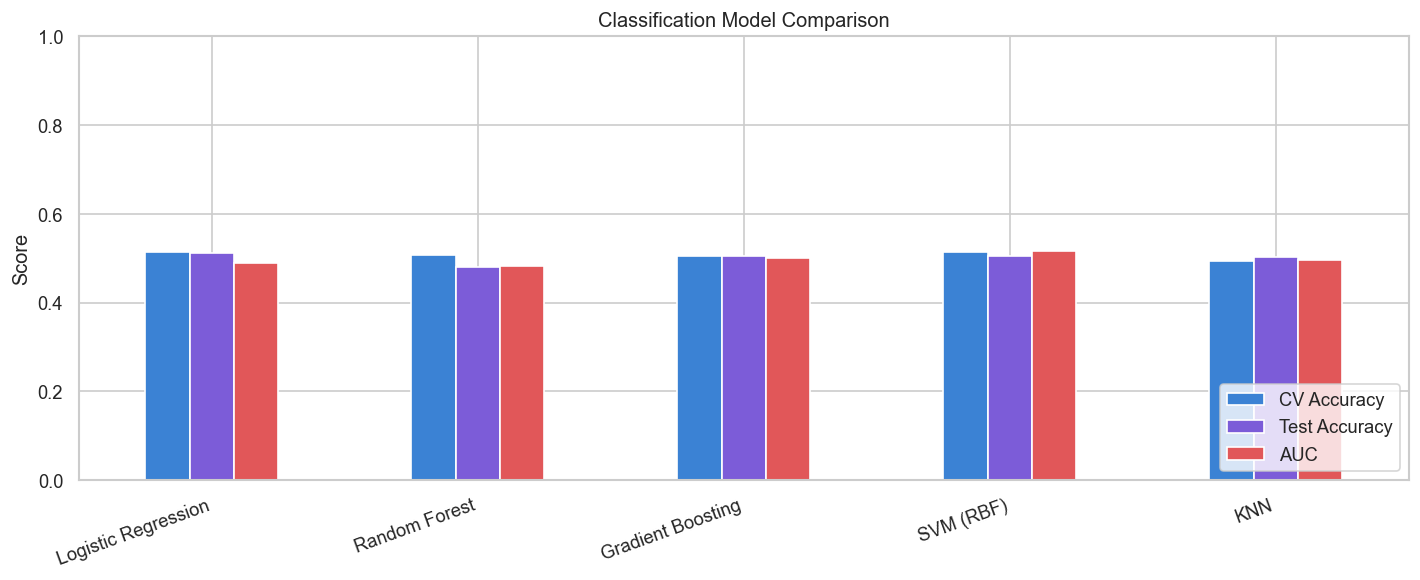

,CV Accuracy,Test Accuracy,AUC
Logistic Regression,0.513750,0.511667,0.490244
Random Forest,0.507917,0.480000,0.481694
Gradient Boosting,0.505833,0.505000,0.500278
SVM (RBF),0.513333,0.505000,0.515145
KNN,0.494583,0.501667,0.495683


In [15]:
# Comparison bar chart
clf_df = pd.DataFrame({
    name: {'CV Accuracy': r['cv_mean'], 'Test Accuracy': r['test_acc'], 'AUC': r['test_auc']}
    for name, r in clf_results.items()
}).T

clf_df[['CV Accuracy','Test Accuracy','AUC']].plot(kind='bar', figsize=(12, 5),
    color=['#3b82d4','#7c5cd8','#e15759'], edgecolor='white')
plt.title('Classification Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
clf_df

In [16]:
# Best classifier by AUC
best_clf_name = max(clf_results, key=lambda k: clf_results[k]['test_auc'])
best_clf = clf_results[best_clf_name]
print(f'Best classifier: {best_clf_name} (AUC={best_clf["test_auc"]:.4f})')

print('\nClassification Report:')
print(classification_report(y_clf_test, best_clf['y_pred'], target_names=['No Issues','Has Issues']))

Best classifier: SVM (RBF) (AUC=0.5151)

Classification Report:
              precision    recall  f1-score   support

   No Issues       0.51      0.53      0.52       302
  Has Issues       0.50      0.48      0.49       298

    accuracy                           0.51       600
   macro avg       0.50      0.50      0.50       600
weighted avg       0.50      0.51      0.50       600



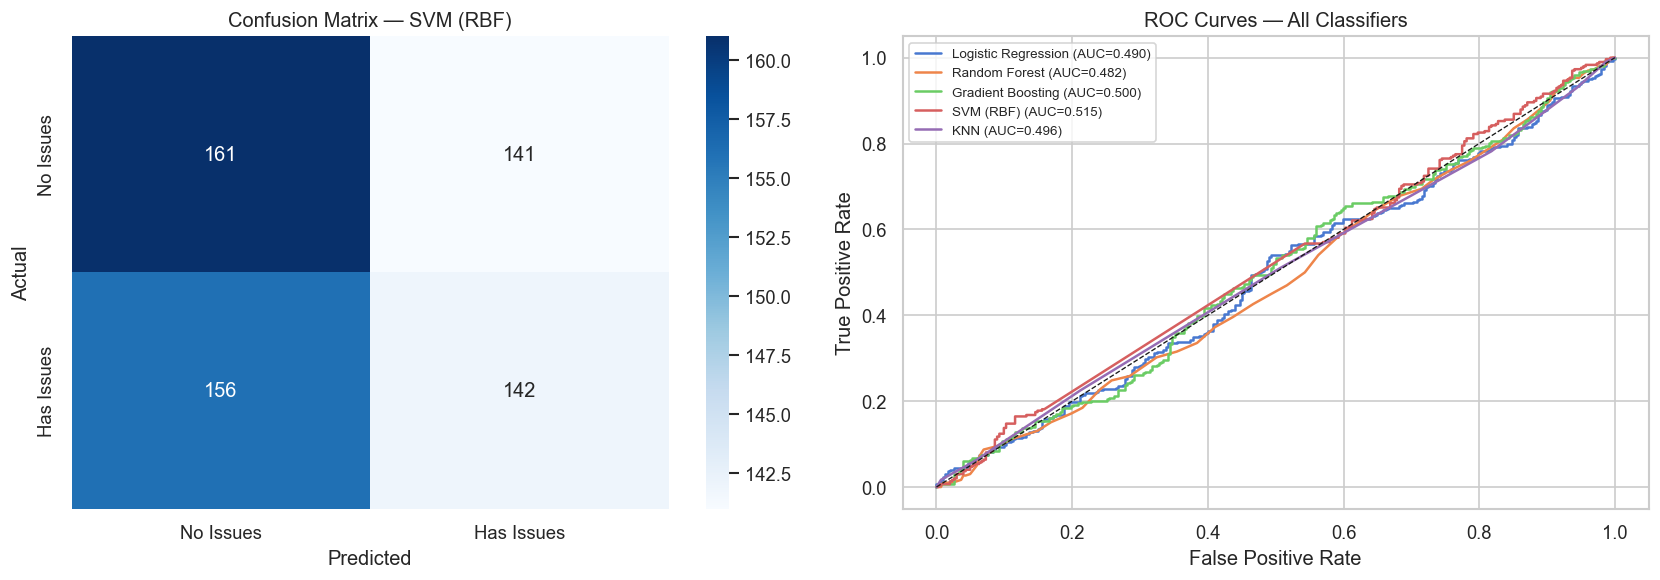

In [17]:
# Confusion matrix + ROC curve for best model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_clf_test, best_clf['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Issues','Has Issues'],
            yticklabels=['No Issues','Has Issues'])
axes[0].set_title(f'Confusion Matrix — {best_clf_name}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curves for all classifiers
for name, r in clf_results.items():
    fpr, tpr, _ = roc_curve(y_clf_test, r['y_proba'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={r['test_auc']:.3f})")
axes[1].plot([0,1],[0,1],'k--', linewidth=0.8)
axes[1].set_title('ROC Curves — All Classifiers')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Regression — Predict `smokes_per_day`

In [18]:
# Regression needs its own preprocessor (same logic, different feature set)
cat_features_reg = X_reg.select_dtypes(include='object').columns.tolist()
num_features_reg = X_reg.select_dtypes(exclude='object').columns.tolist()

preprocessor_reg = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features_reg),
    ('cat', cat_transformer, cat_features_reg)
])

reg_models = {
    'Linear Regression':    LinearRegression(),
    'Ridge Regression':     Ridge(alpha=1.0),
    'Random Forest Reg':    RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting Reg':GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE)
}

reg_results = {}
for name, model in reg_models.items():
    pipe = Pipeline([('pre', preprocessor_reg), ('reg', model)])
    pipe.fit(X_reg_train, y_reg_train)
    y_pred = pipe.predict(X_reg_test)
    mae  = mean_absolute_error(y_reg_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
    r2   = r2_score(y_reg_test, y_pred)
    reg_results[name] = {'pipe': pipe, 'y_pred': y_pred, 'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f'{name:25s} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}')

Linear Regression         | MAE: 0.0000 | RMSE: 0.0000 | R²: 1.0000
Ridge Regression          | MAE: 0.0023 | RMSE: 0.0028 | R²: 1.0000
Random Forest Reg         | MAE: 0.0760 | RMSE: 0.2547 | R²: 0.9935
Gradient Boosting Reg     | MAE: 0.0567 | RMSE: 0.1084 | R²: 0.9988


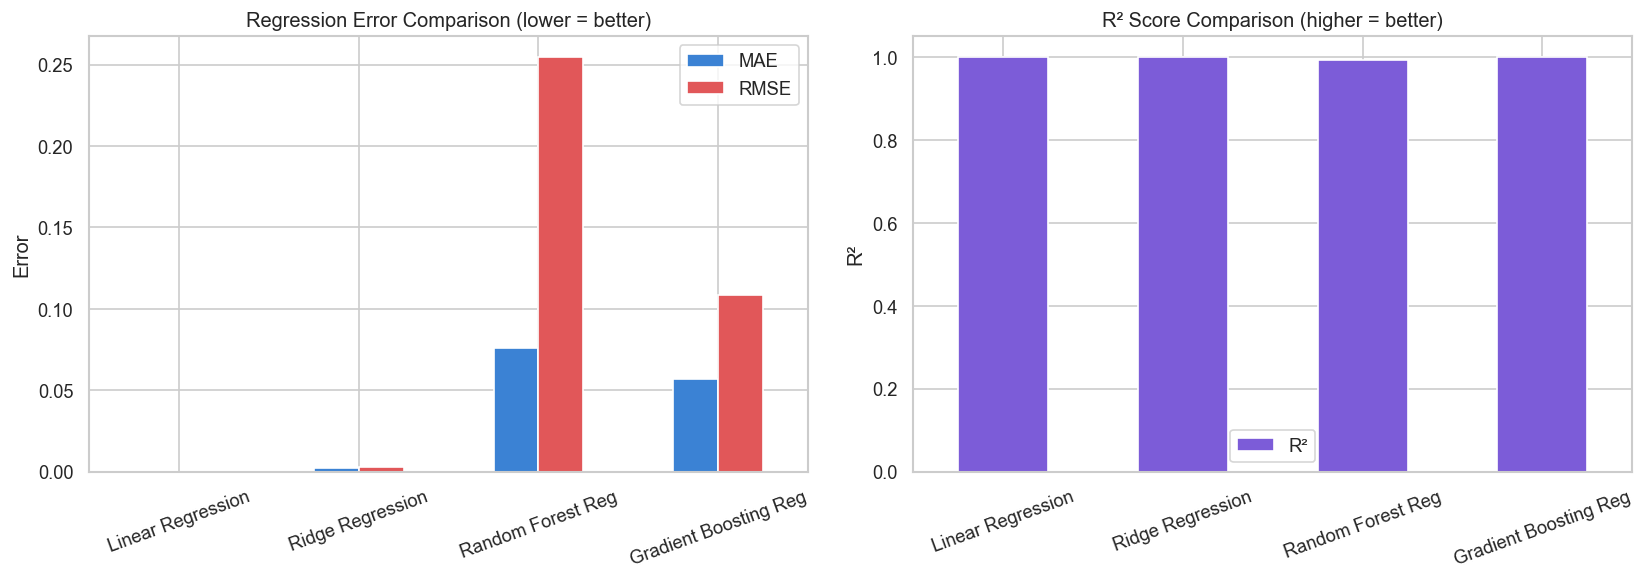

,MAE,RMSE,R²
Linear Regression,1.106670e-14,1.271513e-14,1.000000
Ridge Regression,2.276948e-03,2.834632e-03,0.999999
Random Forest Reg,7.604167e-02,2.547171e-01,0.993545
Gradient Boosting Reg,5.673797e-02,1.083717e-01,0.998831


In [19]:
# Regression comparison
reg_df = pd.DataFrame({
    name: {'MAE': r['MAE'], 'RMSE': r['RMSE'], 'R²': r['R2']}
    for name, r in reg_results.items()
}).T

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
reg_df[['MAE','RMSE']].plot(kind='bar', ax=axes[0], color=['#3b82d4','#e15759'], edgecolor='white')
axes[0].set_title('Regression Error Comparison (lower = better)')
axes[0].set_ylabel('Error')
axes[0].tick_params(axis='x', rotation=20)

reg_df[['R²']].plot(kind='bar', ax=axes[1], color='#7c5cd8', edgecolor='white')
axes[1].set_title('R² Score Comparison (higher = better)')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
reg_df

Best regressor: Linear Regression (R²=1.0000)


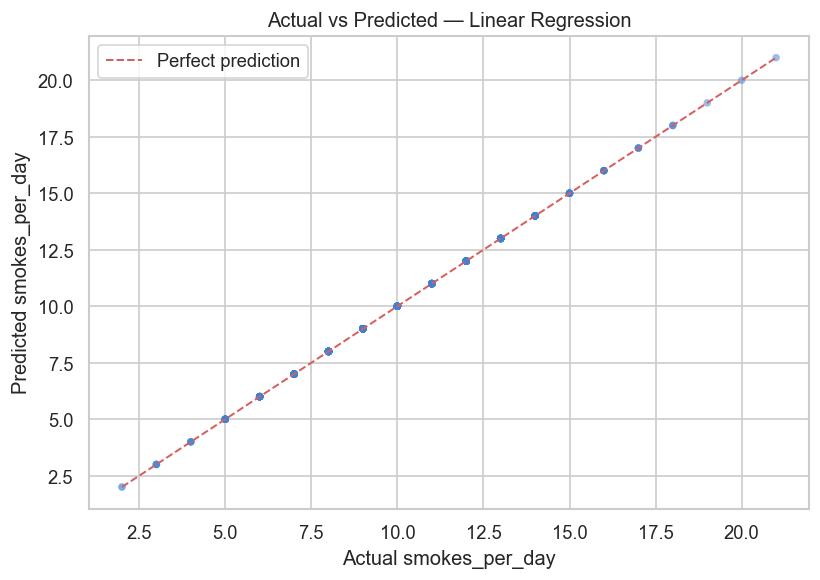

In [20]:
# Best regression model — Actual vs Predicted
best_reg_name = max(reg_results, key=lambda k: reg_results[k]['R2'])
best_reg = reg_results[best_reg_name]
print(f'Best regressor: {best_reg_name} (R²={best_reg["R2"]:.4f})')

plt.figure(figsize=(7, 5))
plt.scatter(y_reg_test, best_reg['y_pred'], alpha=0.3, color='#3b82d4', edgecolors='none', s=20)
lims = [y_reg_test.min(), y_reg_test.max()]
plt.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect prediction')
plt.xlabel('Actual smokes_per_day')
plt.ylabel('Predicted smokes_per_day')
plt.title(f'Actual vs Predicted — {best_reg_name}')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Feature Importance

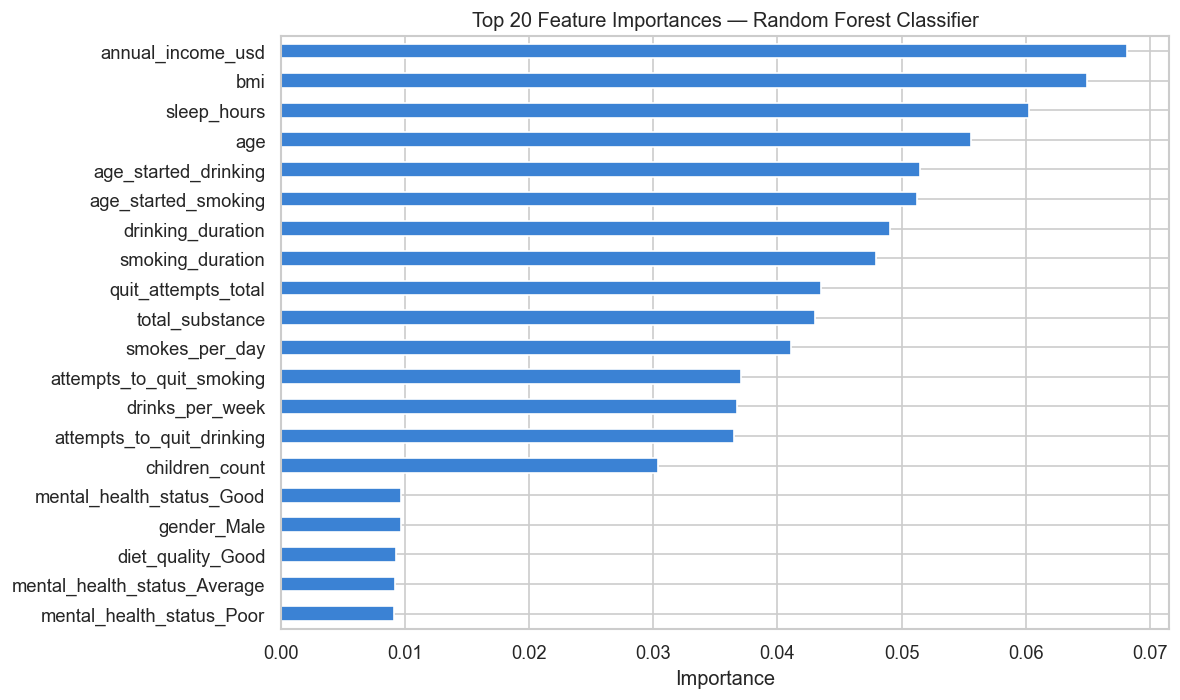

In [21]:
def get_feature_names(preprocessor, num_features, cat_features):
    """Extract feature names after ColumnTransformer."""
    cat_enc = preprocessor.named_transformers_['cat']['encoder']
    cat_names = cat_enc.get_feature_names_out(cat_features).tolist()
    return num_features + cat_names

# --- Classification: Random Forest importances ---
rf_clf_pipe = clf_results['Random Forest']['pipe']
feature_names_clf = get_feature_names(rf_clf_pipe.named_steps['pre'], num_features, cat_features)
importances_clf = rf_clf_pipe.named_steps['clf'].feature_importances_
imp_clf_df = pd.Series(importances_clf, index=feature_names_clf).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
imp_clf_df.plot(kind='barh', color='#3b82d4', edgecolor='white')
plt.title('Top 20 Feature Importances — Random Forest Classifier')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

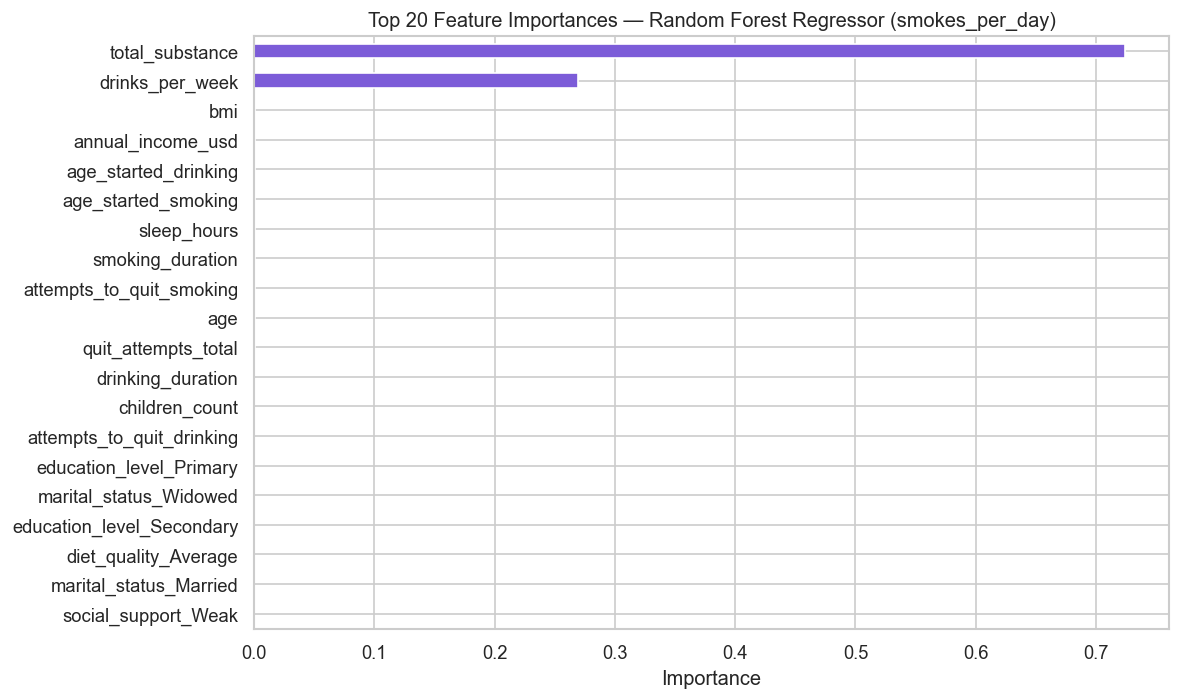

In [22]:
# --- Regression: Random Forest importances ---
rf_reg_pipe = reg_results['Random Forest Reg']['pipe']
feature_names_reg = get_feature_names(rf_reg_pipe.named_steps['pre'], num_features_reg, cat_features_reg)
importances_reg = rf_reg_pipe.named_steps['reg'].feature_importances_
imp_reg_df = pd.Series(importances_reg, index=feature_names_reg).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
imp_reg_df.plot(kind='barh', color='#7c5cd8', edgecolor='white')
plt.title('Top 20 Feature Importances — Random Forest Regressor (smokes_per_day)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Model Persistence

In [23]:
# Save best classification pipeline
joblib.dump(best_clf['pipe'], 'best_classifier.pkl')
print(f'Best classifier saved → best_classifier.pkl  ({best_clf_name})')

# Save best regression pipeline
joblib.dump(best_reg['pipe'], 'best_regressor.pkl')
print(f'Best regressor saved  → best_regressor.pkl  ({best_reg_name})')

Best classifier saved → best_classifier.pkl  (SVM (RBF))
Best regressor saved  → best_regressor.pkl  (Linear Regression)


## 9. Quick Inference Example

In [25]:
# Load and run inference on a sample record
clf_model = joblib.load('best_classifier.pkl')

sample = pd.DataFrame([{
    'age': 45, 'gender': 'Male', 'education_level': 'University',
    'employment_status': 'Employed', 'annual_income_usd': 55000,
    'marital_status': 'Married', 'children_count': 2,
    'smokes_per_day': 10, 'drinks_per_week': 5,
    'age_started_smoking': 18, 'age_started_drinking': 20,
    'attempts_to_quit_smoking': 2, 'attempts_to_quit_drinking': 1,
    'mental_health_status': 'Average', 'exercise_frequency': 'Weekly',
    'diet_quality': 'Average', 'sleep_hours': 6.5, 'bmi': 27.0,
    'social_support': 'Moderate', 'therapy_history': 'None',
    'smoking_duration': 27, 'drinking_duration': 25,
    'total_substance': 15, 'quit_attempts_total': 3
}])

prediction = clf_model.predict(sample)[0]
probability = clf_model.predict_proba(sample)[0][1]

print(f'Prediction  : {"Has Health Issues" if prediction == 1 else "No Health Issues"}')
print(f'Probability : {probability:.4f}')

Prediction  : Has Health Issues
Probability : 0.5000


---
**End of Notebook** — Models trained, evaluated, and saved successfully.